In [1]:
from kafka import KafkaConsumer, TopicPartition
import json
import numpy as np
import matplotlib.mlab as mlab
from sklearn.ensemble import IsolationForest
import os
import time
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from collections import defaultdict
from baskervillehall.baskervillehall_isolation_forest import BaskervillehallIsolationForest

plt.rcParams["figure.figsize"] = (15,5)

In [2]:
kafka_url = ['kafka9-0.kafka9-headless.default.svc.cluster.local:9093','kafka9-1.kafka9-headless.default.svc.cluster.local:9093','kafka9-2.kafka9-headless.default.svc.cluster.local:9093']
topic = 'BASKERVILLEHALL_3'
partitions = {
    'zhitomir.info': 1,
    'urban-pushkino.ru': 0,
    'dev.emawpb.org': 0,
    'palestinechronicle.com': 1,
    'equalit.ie': 0,
    'lexota.org': 0,
    'kavkaz-uzel.eu': 0,
    'amp.kavkaz-uzel.eu': 2,
    'indymedia.nl': 0,
    'verafiles.org': 1,
}

In [3]:
host = 'verafiles.org'
datetime_format = '%Y-%m-%d %H:%M:%S'

dataset_size = 7000
num_urls = 500
min_hits_for_url = 10
num_total_pca_components = 1000
target_explained_variance = 0.98
target_false_positive_rate = 0.05
warmup_period = 3

In [4]:
def read_dataset(partition):
    consumer = KafkaConsumer(
        bootstrap_servers=kafka_url,
        group_id='anton11'
    )
    
    vectors = []
    ids = []
    durations = []
    countries = []
    country_map = defaultdict(int)
    num = 0
    
    print(f'Reading from kafka. Host = {host} ... partition = {partition}')
    time_now = int(time.time())
    sessions = []
    url_dict = {}
    ids = []

    consumer.assign([TopicPartition(topic, partition)])
    consumer.seek_to_beginning()
    complete = False
    while not complete:
        raw_messages = consumer.poll(timeout_ms=1000, max_records=5000)

        for topic_partition, messages in raw_messages.items():
            for message in messages:
                # prevent from getting messages too close to the current time
                time_diff_in_minutes = (time_now - message.timestamp / 1000) / 60
                if time_diff_in_minutes < 2:
                    print(f'{time_diff_in_minutes} minutes. Topic offset is too close to the current times...')
                    complete = True
                    break
                
                if message.value is None :
                    continue
                if message.key is None:
                    continue
                if message.key.decode("utf-8") != host:
                    continue
                   
                value = json.loads(message.value.decode("utf-8"))
                value['duration'] = abs(value['duration'])
                duration = value['duration']
                if duration < 1:
                    continue
                if duration > 300:
                    continue
                if len(value['requests']) < 3:
                    continue
                durations.append(duration)
                session = []
                requests_original = value.get('requests', [])

                if len(requests_original) > 0 and isinstance(requests_original[0]['ts'], str):
                    timestamps = [datetime.strptime(r['ts'], datetime_format) for r in requests_original]
                else:
                    timestamps = [r['ts'] for r in requests_original]
            
                session.append(requests_original[0]['url'])
                for i in range(1, len(requests_original)):
                    if (timestamps[i] - timestamps[0]).total_seconds() > warmup_period:
                        url = requests_original[i]['url']
                        url_dict[url] = url_dict.get(url, 0) + 1
                        session.append(url)
                sessions.append(session)
                ids.append(value['ip'])
                    
                if num == dataset_size:
                    complete = True
                    break
                num += 1
                if num % 100 == 0:
                    print(f'{num} sessions read', value['end'], message.timestamp)
            
    return url_dict, sessions, ids, durations

In [5]:
url_dict, sessions, ids, durations = read_dataset(partitions[host])

Reading from kafka. Host = verafiles.org ... partition = 1
100 sessions read 2023-12-25 11:03:08 1703502190590
200 sessions read 2023-12-25 11:32:16 1703504118596
300 sessions read 2023-12-25 11:56:45 1703505526219
400 sessions read 2023-12-25 12:18:29 1703507001858
500 sessions read 2023-12-25 12:48:11 1703508493779
600 sessions read 2023-12-25 13:13:30 1703510021191
700 sessions read 2023-12-25 13:33:57 1703511509200
800 sessions read 2023-12-25 14:03:56 1703513249719
900 sessions read 2023-12-25 14:43:46 1703515428215
1000 sessions read 2023-12-25 15:18:54 1703517536338
1100 sessions read 2023-12-25 15:56:17 1703519778371
1200 sessions read 2023-12-25 16:46:08 1703522771417
1300 sessions read 2023-12-25 17:27:45 1703525563625
1400 sessions read 2023-12-25 18:23:52 1703528634685
1500 sessions read 2023-12-25 19:40:49 1703533252650
1600 sessions read 2023-12-25 20:04:09 1703534659262
1700 sessions read 2023-12-25 20:19:15 1703535563126
1800 sessions read 2023-12-25 20:46:22 1703537193

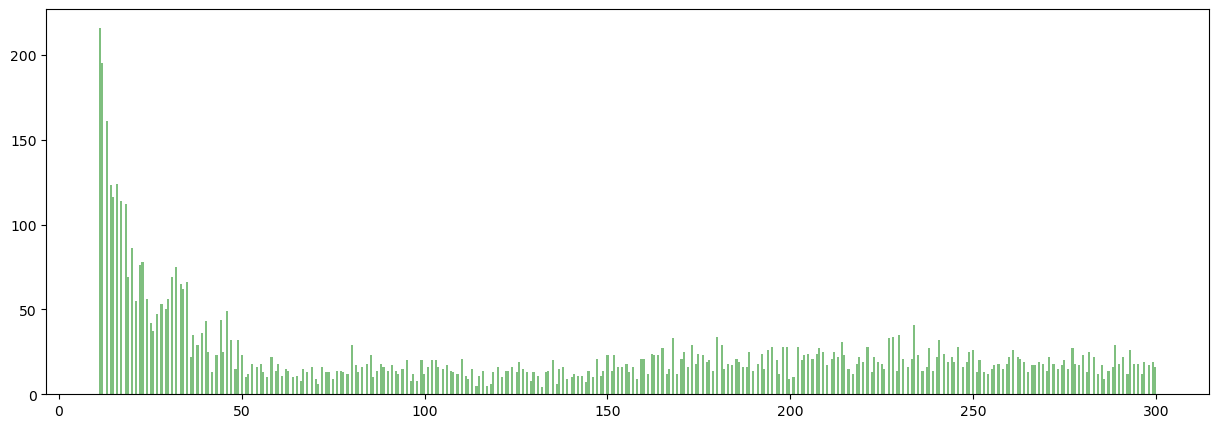

In [6]:
n, bins, patches = plt.hist(durations, 500, facecolor='green', alpha=0.5)
plt.rcParams["figure.figsize"] = (22,5)
plt.show()

In [7]:
all_urls = sorted([(k, v) for k, v in url_dict.items()], key = lambda v: v[1], reverse=True)
actual_num_urls = min(num_urls, len(all_urls))
for i in range(actual_num_urls):
    if(all_urls[i][1] < min_hits_for_url):
        actual_num_urls = i
        break
    
url_index = {all_urls[i][0]: i for i in range(actual_num_urls)}
url_index['tail'] = len(url_index)
url_index['not_existing'] = len(url_index)
print(f'actual_num_urls = {actual_num_urls}')

actual_num_urls = 500


In [8]:
for i in range(30):
    url = list(url_index.keys())[i]
    print(f'{i}, {url} = {url_dict[url]} ')

0, / = 684933 
1, /502.html = 13625 
2, /wp-content/themes/twentytwenty/assets/fonts/inter/Inter-upright-var.woff2 = 2406 
3, /wp-content/themes/twentytwenty/assets/fonts/inter/Inter-italic-var.woff2 = 2389 
4, /wp-content/plugins/sticky-buttons-pro/vendors/fontawesome/webfonts/fa-solid-900.woff2 = 2311 
5, /wp-content/plugins/sticky-buttons-pro/vendors/fontawesome/webfonts/fa-brands-400.woff2 = 2296 
6, /wp-content/uploads/2022/04/verafiles-logo-banner.png = 2223 
7, /wp-content/uploads/2022/03/verafiles-logo-small.jpg = 2068 
8, /wp-admin/admin-ajax.php = 2025 
9, /wp-content/plugins/amp/assets/fonts/nonbreakingspaceoverride.woff2 = 1853 
10, /wp-content/plugins/sticky-buttons-pro/vendors/fontawesome/webfonts/fa-brands-400.woff = 1816 
11, /wp-content/plugins/sticky-buttons-pro/vendors/fontawesome/webfonts/fa-solid-900.woff = 1780 
12, /articles = 1243 
13, /articles/vera-files-fact-check-simon-cowell-subject-of-a-death-hoax-once-again = 1229 
14, /wp-content/uploads/2022/07/Digital_

In [9]:
def create_sample(
    urls, 
    url_index,
    url_dict
):
    sample = np.zeros(len(url_index))
    for url in urls:
        if url in url_index:
            sample[url_index[url]] += 1
        elif url in url_dict:
            sample[url_index['tail']] += 1          
        else:
            sample[url_index['not_existing']] += 10
            
    return sample

def create_dataset(sessions, url_index, url_dict):
    dataset = []
    num = 0
    for urls in sessions:
        sample = create_sample(urls, url_index, url_dict)
        dataset.append(sample)
        num += 1
        if num % 1000 == 0:
            print(f'{num} samples created')
    return np.array(dataset)

In [10]:
Y = create_dataset(
    sessions,
    url_index,
    url_dict
)
ips = np.array(ids)

1000 samples created
2000 samples created
3000 samples created
4000 samples created
5000 samples created
6000 samples created
7000 samples created


In [11]:
Y.shape

(7001, 502)

In [12]:
indices = np.random.permutation(Y.shape[0])
num_train = int(0.8 * Y.shape[0])
training_idx, validate_idx = indices[:num_train], indices[num_train:]
Y_train, ips_train = Y[training_idx, :], ips[training_idx]
Y_validate, ips_validate = Y[validate_idx, :], ips[validate_idx]

In [13]:
mean = Y_train.mean(axis=0)
std = Y_train.std(axis=0)
print(f'zero dimensions : {std[std == 0].shape}, {std[std == 0].shape[0] *100/ len(std):.1f}%')
std[std == 0] = 1
Z = (Y_train - mean) / std
Z[np.isnan(Z)] = 0

zero dimensions : (0,), 0.0%


In [14]:
total_pca_components = min(num_total_pca_components, len(url_index), len(Y_train))
total_pca_components

502

In [15]:
from sklearn.decomposition import PCA
pca = PCA(n_components=total_pca_components)
pca.fit(Z)


PCA(n_components=502)

In [16]:
# find the number of pca components
explained_variance = pca.explained_variance_ratio_.cumsum()
num_components = total_pca_components
for i in range(len(explained_variance)):
    # print(f'{i}, {explained_variance[i]}')
    if explained_variance[i] >= target_explained_variance:
        num_components = i
        break
print(f'\nNumber of PCA components = {num_components}')



Number of PCA components = 336


# Subspace method

In [17]:
components = pca.components_[:num_components,:].transpose()
PPT = np.dot(components, components.transpose())
C2 = np.identity(components.shape[0]) - PPT

In [18]:
def score(Y, mean, std, C2):
    Z = (Y - mean) / std
    Z[np.isnan(Z)] = 0
    Z = np.matmul(C2, Z.transpose())
    Z[np.isnan(Z)] = 0
    res = (Z**2).mean(axis=0)
    return res

In [19]:
score_train = score(Y_train, mean, std, C2)
score_validate = score(Y_validate, mean, std, C2)

In [20]:
def false_positive_rate(score_train, ips, threshold):
    ip_prediction = {}
    for ip, score in zip(ips, score_train):
        if score > threshold:
            ip_prediction[ip] = 1
        else:
            if ip not in ip_prediction:
                ip_prediction[ip] = 0

    return len([prediction for _, prediction in ip_prediction.items() if prediction > 0]) / len(ip_prediction.keys())

In [21]:
# find the threshold
print('Finding threshold...')
threshold = 0
fpr = 0.0
while threshold < 10.0:
    fpr = len(score_train[score_train > threshold]) / len(score_train)
    # print(f'threshold={threshold}, false_positive_rate={fpr}')
    if fpr < target_false_positive_rate:
        break
    threshold += 0.01
print(f'Threshold = {threshold:.2f}, false_positive_rate = {fpr:.2f}\n')

Finding threshold...
Threshold = 0.10, false_positive_rate = 0.05



In [22]:
print(f'train cut = {len(score_train[score_train > threshold]) / len(score_train)}, validate cut = {len(score_validate[score_validate > threshold]) / len(score_validate)}')
print(f'train FPR = {false_positive_rate(score_train, ips_train, threshold)}, validate FPR = {false_positive_rate(score_validate, ips_validate, threshold)}')

train cut = 0.046964285714285715, validate cut = 0.07137758743754462
train FPR = 0.10574521232306411, validate FPR = 0.10701754385964912


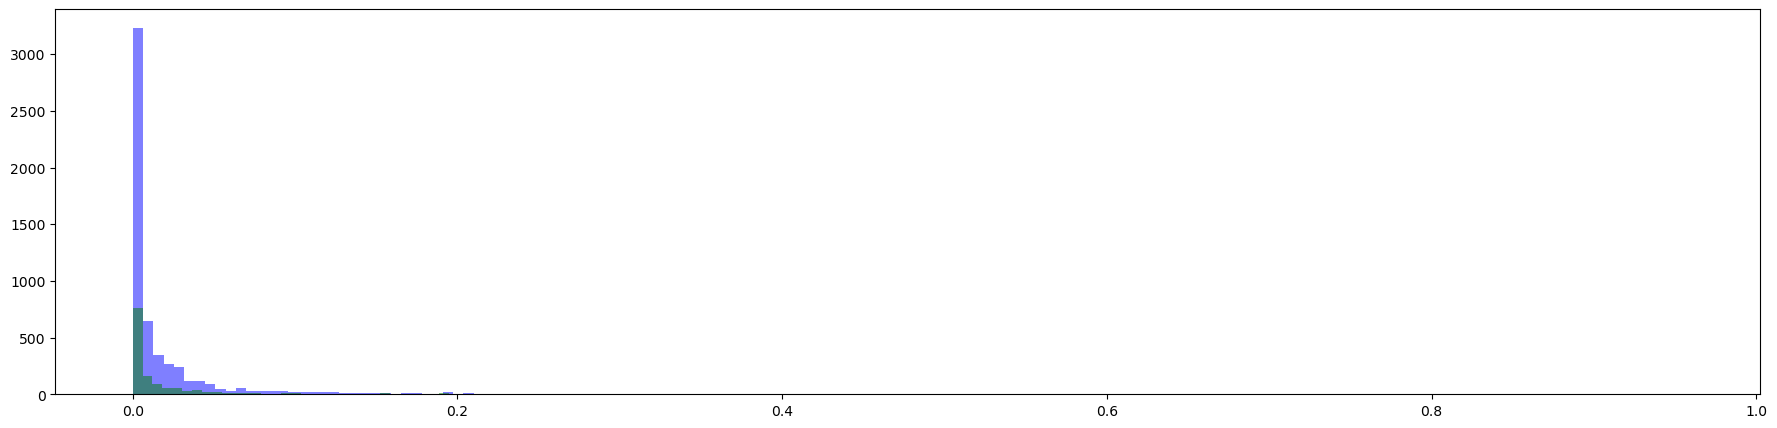

In [23]:
n, bins, patches = plt.hist(score_train[score_train < 1], 150, facecolor='blue', alpha=0.5)
n, bins, patches = plt.hist(score_validate[score_validate < 1], 150, facecolor='green', alpha=0.5)
plt.show()

In [24]:
print(f'Threshold = {threshold}')
print(score(Y[0], mean, std, C2))

Threshold = 0.09999999999999999
0.0018174824124371238


# Random walk

In [39]:
from random import randrange
top_urls =  1
num_hits = 30

random_walk = [randrange(top_urls) for i in range(num_hits)]
urls = []
ts = datetime.now()
for i in range(len(random_walk)):
    url = all_urls[random_walk[i]][0]
    urls.append(url)

Y_rw = np.array([create_sample(urls, url_index, url_dict)])
print(f'Threshold = {threshold}')
print(score(Y_rw, mean, std, C2))

Threshold = 0.09999999999999999
[6.40341204e-05]


# Home page

In [42]:
num_hits = 340
urls = []

url = '/'
# url = all_urls[0][0]

print(url)
for i in range(num_hits):
    urls.append(url)
    
Y_rw = np.array([create_sample(urls, url_index, url_dict)])
print(f'Threshold = {threshold}')
print(score(Y_rw, mean, std, C2))

/
Threshold = 0.09999999999999999
[3.09786378e-05]
